In [1]:
from treys import Card, Evaluator, Deck
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class RangeParser:
    SUITS = ['s', 'h', 'd', 'c']
    RANKS = '23456789TJQKA'
    
    @staticmethod
    def get_all_combos(rank1, rank2, suited=None):
        combos = []
        if rank1 == rank2:
            for s1, s2 in itertools.combinations(RangeParser.SUITS, 2):
                combos.append([rank1 + s1, rank2 + s2])
        elif suited is True:
            for s in RangeParser.SUITS:
                combos.append([rank1 + s, rank2 + s])
        elif suited is False:
            for s1 in RangeParser.SUITS:
                for s2 in RangeParser.SUITS:
                    if s1 != s2:
                        combos.append([rank1 + s1, rank2 + s2])
        else:
            for s1 in RangeParser.SUITS:
                for s2 in RangeParser.SUITS:
                    if s1 == s2 or s1 != s2: 
                        if rank1 + s1 != rank2 + s2:
                            hand = sorted([rank1 + s1, rank2 + s2], key=lambda x: RangeParser.RANKS.find(x[0]), reverse=True)
                            if hand not in combos:
                                combos.append(hand)
        return combos

    def parse_range(self, range_str):
        final_range = []
        parts = [p.strip() for p in range_str.split(',')]
        
        for part in parts:
            if '+' in part:
                base = part.replace('+', '')
                r1, r2 = base[0], base[1]
                type_suffix = base[2:] if len(base) > 2 else ""
                idx1, idx2 = self.RANKS.find(r1), self.RANKS.find(r2)
                
                if idx1 == idx2: 
                    for i in range(idx1, len(self.RANKS)):
                        final_range.extend(self.get_all_combos(self.RANKS[i], self.RANKS[i]))
                else: 
                    for i in range(idx2, idx1):
                        suited = True if 's' in type_suffix else (False if 'o' in type_suffix else None)
                        final_range.extend(self.get_all_combos(r1, self.RANKS[i], suited))
            elif '-' in part:
                pass
            else:
                if len(part) == 4: 
                    final_range.append([part[:2], part[2:]])
                elif len(part) == 3: 
                    final_range.extend(self.get_all_combos(part[0], part[1], part[2] == 's'))
                elif len(part) == 2: 
                    final_range.extend(self.get_all_combos(part[0], part[1]))
                    
        return final_range

In [3]:
class BayesianOpponentRange:
    def __init__(self, raw_parsed_range):
        self.hand_weights = {tuple(hand): 1.0 for hand in raw_parsed_range} #weights initialized to 1.0
        self.evaluator = Evaluator()

    def apply_action_likelihood(self, action_type, board_strs):
        """
        Bayesian Posterior Update Layer: P(Hand | Action) = P(Action | Hand) * P(Hand)
        """
        board_cards = [Card.new(c) for c in board_strs]
        
        for hand_tuple in list(self.hand_weights.keys()):
            prior_weight = self.hand_weights[hand_tuple]
            if prior_weight == 0.0:
                continue
                
            hand_cards = [Card.new(hand_tuple[0]), Card.new(hand_tuple[1])]
            
            # Dead card validation
            if len(set(hand_cards + board_cards)) < (len(hand_cards) + len(board_cards)):
                self.hand_weights[hand_tuple] = 0.0
                continue
            
            # Determine likelihood mapping: P(Action | Hand Strength)
            likelihood = self._calculate_likelihood(hand_cards, board_cards, action_type)
            
            # Posterior Update
            self.hand_weights[hand_tuple] = prior_weight * likelihood

    def _calculate_likelihood(self, hand_cards, board_cards, action_type):
        raw_score = self.evaluator.evaluate(hand_cards, board_cards)
        
        if action_type == "AGGRESSIVE_FLOP_CBET":
            if raw_score <= 1600:      # Strong hands: Sets, Two Pairs, Overpairs
                return 0.95            # 95% chance they bet these aggressively
            elif raw_score <= 6185:    # Medium strength / Draws
                return 0.60            # 60% chance they semi-bluff or c-bet
            else:                      # Weak air
                return 0.15            # 15% pure air bluff probability
                
        return 1.0

    def get_weighted_arrays(self):
        combos = list(self.hand_weights.keys())
        weights = list(self.hand_weights.values())
        return combos, weights

In [4]:
def range_vs_range_equity(hero_hand_strs, bayesian_villain_range, board_strs, n_simulations=10000):
    evaluator = Evaluator()
    hero_hand = [Card.new(c) for c in hero_hand_strs]
    board = [Card.new(c) for c in board_strs]
    
    combos, weights = bayesian_villain_range.get_weighted_arrays()
    
    if sum(weights) == 0:
        raise ValueError("Error: Opponent has zero valid combinations remaining under current Bayesian priors.")
        
    hero_wins = 0
    ties = 0
    actual_simulations = 0
    
    for _ in range(n_simulations):
        # OPTIMIZATION: Sample according to Bayesian posterior probability weights
        chosen_tuple = random.choices(combos, weights=weights, k=1)[0]
        villain_hand = [Card.new(chosen_tuple[0]), Card.new(chosen_tuple[1])]
        
        all_dead_cards = set(hero_hand + board + villain_hand)
        if len(all_dead_cards) < (len(hero_hand) + len(board) + len(villain_hand)):
            continue
            
        full_deck = Deck()
        remaining_cards = [c for c in full_deck.cards if c not in all_dead_cards]
        needed = 5 - len(board)
        sim_board = board + random.sample(remaining_cards, needed)
        
        hero_score = evaluator.evaluate(hero_hand, sim_board)
        villain_score = evaluator.evaluate(villain_hand, sim_board)
        
        if hero_score < villain_score:
            hero_wins += 1
        elif hero_score == villain_score:
            ties += 1
        actual_simulations += 1
            
    if actual_simulations == 0:
        return 0.0
    return (hero_wins + (ties * 0.5)) / actual_simulations

In [5]:
def plot_range_heatmap(bayesian_opponent, title="Opponent Range Heatmap"):
    ranks = 'AKQJT98765432'
    grid = np.zeros((13, 13))
    
    combo_max_weights = {}
    
    for (card1, card2), weight in bayesian_opponent.hand_weights.items():
        r1, s1 = card1[0], card1[1]
        r2, s2 = card2[0], card2[1]
        
        if r1 == r2:
            combo_str = r1 + r2
        elif s1 == s2:
            # Sort by rank index to ensure higher rank is always first
            high_r = r1 if ranks.find(r1) < ranks.find(r2) else r2
            low_r = r2 if high_r == r1 else r1
            combo_str = high_r + low_r + 's'
        else:
            high_r = r1 if ranks.find(r1) < ranks.find(r2) else r2
            low_r = r2 if high_r == r1 else r1
            combo_str = high_r + low_r + 'o'
            
        if combo_str not in combo_max_weights:
            combo_max_weights[combo_str] = []
        combo_max_weights[combo_str].append(weight)

    # Place mean/max weights into their exact grid coordinates
    for i, r1 in enumerate(ranks):
        for j, r2 in enumerate(ranks):
            if i == j: # Pairs (Diagonal)
                combo = r1 + r2
            elif i < j: # Suited (Top Right)
                combo = r1 + r2 + 's'
            else: # Offsuit (Bottom Left)
                combo = r2 + r1 + 'o'
                
            if combo in combo_max_weights:
                grid[i, j] = np.mean(combo_max_weights[combo])

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        grid, 
        annot=True, 
        fmt=".2f", 
        cmap="YlGnBu", 
        xticklabels=list(ranks), 
        yticklabels=list(ranks),
        vmin=0.0, 
        vmax=1.0,
        cbar_kws={'label': 'Bayesian Range Weight Presence'}
    )
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.show()

In [6]:
def compute_call_ev(equity, pot, call_cost, future_cost=0):
    return equity * (pot + call_cost) - call_cost - future_cost

def calculate_kelly_allocation(equity, pot, call_cost, total_bankroll):
    """
    Computes optimal portfolio allocation percentage using: f* = (bp - q) / b
    """
    p = equity
    q = 1.0 - p
    
    b = pot / call_cost if call_cost > 0 else 0
    
    if b == 0:
        return 0.0, 0.0
        
    kelly_fraction = (b * p - q) / b
    fractional_cap = max(0.0, kelly_fraction * 0.25) 
    suggested_capital_bet = fractional_cap * total_bankroll
    
    return kelly_fraction, suggested_capital_bet

def breakeven_equity(pot, call_cost):
    breakeven_eq = call_cost / (pot + call_cost)
    return breakeven_eq

def decide_call_or_fold(equity, pot, call_cost, total_bankroll=10000):
    call_ev = compute_call_ev(equity, pot, call_cost)
    be_eq = breakeven_equity(pot, call_cost)
    
    kelly_frac, capital_allocation = calculate_kelly_allocation(equity, pot, call_cost, total_bankroll)
    decision = "CALL" if call_ev > 0 else "FOLD"

    print("🏆 ==================== REAL-TIME DECISION ENGINE ====================")
    print(f"Equity Metrics      : Hero Equity: {equity:.2%} | Break-Even Requirement: {be_eq:.2%}")
    print(f"Expected Value (EV) : Immediate Action Value: {call_ev:.4f} units")
    print(f"Strategic Decision  : [ {decision} ]")
    print("-" * 70)
    print("🎲 ==================== KELLY OPTIMAL RISK ALLOCATION ====================")
    if kelly_frac > 0:
        print(f"Theoretical Kelly Fraction : +{kelly_frac:.2%}")
        print(f"Quarter-Kelly Risk Buffer  : Allocate {kelly_frac*0.25:.2%} of liquid reserves")
        print(f"Target Allocation Amount   : ${capital_allocation:.2f} (Total Bankroll Portfolio Base: ${total_bankroll})")
    else:
        print("Theoretical Kelly Fraction : Negative Expectation Area (Betting Blocked)")
        print("Target Allocation Amount   : $0.00 (Capital Preservation Lockdown Mode)")
    print("========================================================================\n")

🏆 ==================== REAL-TIME DECISION ENGINE ====================
Equity Metrics      : Hero Equity: 33.81% | Break-Even Requirement: 25.00%
Expected Value (EV) : Immediate Action Value: 17.6254 units
Strategic Decision  : [ CALL ]
----------------------------------------------------------------------
🎲 ==================== KELLY OPTIMAL RISK ALLOCATION ====================
Theoretical Kelly Fraction : +11.75%
Quarter-Kelly Risk Buffer  : Allocate 2.94% of liquid reserves
Target Allocation Amount   : $734.39 (Total Bankroll Portfolio Base: $25000)



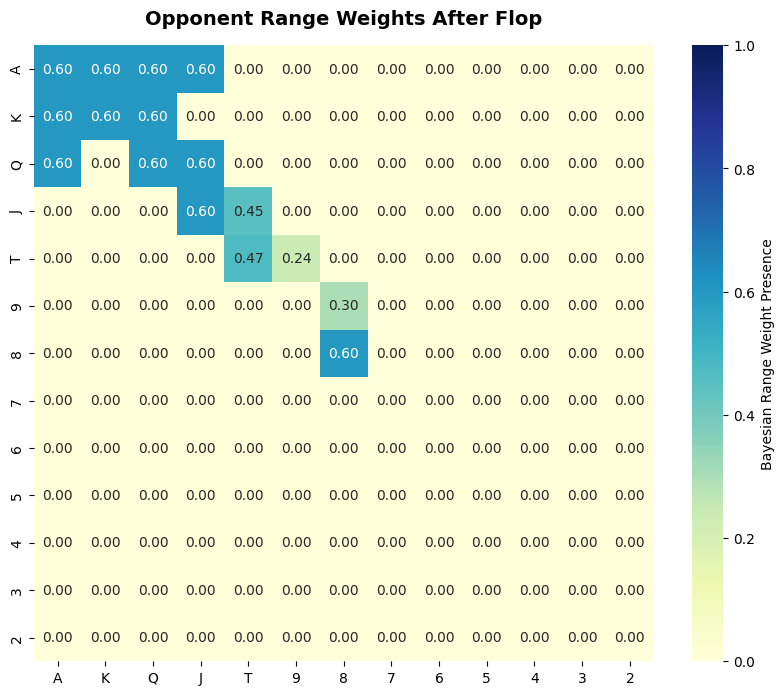

In [9]:
parser = RangeParser()
hero = ['Jh', 'Qs']
flop = ['9d', '9h', 'Ts']
pot = 150
call_cost = 50
bankroll = 25000

raw_range = parser.parse_range("TT+,88,AJs+,KQs,QJs,JTs,T9s,98s,AQo+")
opponent_profile = BayesianOpponentRange(raw_range)
opponent_profile.apply_action_likelihood("AGGRESSIVE_FLOP_CBET", flop)
posterior_equity = range_vs_range_equity(hero, opponent_profile, flop, n_simulations=5000)
decide_call_or_fold(posterior_equity, pot, call_cost, total_bankroll=bankroll)
plot_range_heatmap(opponent_profile, title="Opponent Range Weights After Flop")